In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GroupKFold, StratifiedKFold, train_test_split, cross_validate, GridSearchCV
from sklearn.metrics import classification_report, precision_score, recall_score, accuracy_score, confusion_matrix, roc_curve, precision_recall_curve, auc, f1_score
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.feature_selection import RFE, SelectFromModel
from xgboost import XGBClassifier, plot_importance
from IPython import display
from datetime import datetime
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor

import matplotlib.pyplot as plt
from matplotlib import cm

from pylab import rcParams

import os
import re
import time

seed = 9001
np.random.seed(seed)

In [2]:
X = pd.read_csv('/kaggle/input/non-temporal-processed/non_temporal_processed.csv')

In [3]:
# Event-wise distribution
event_dist = X['SepsisLabel'].value_counts(normalize=True) * 100
print("Event-wise distribution (%)")
print(event_dist)

# Patient-wise distribution
patient_label = X.groupby('id')['SepsisLabel'].max()
patient_dist = patient_label.value_counts(normalize=True) * 100
print("\nPatient-wise distribution (%)")
print(patient_dist)


Event-wise distribution (%)
SepsisLabel
0    98.201532
1     1.798468
Name: proportion, dtype: float64

Patient-wise distribution (%)
SepsisLabel
0    92.731059
1     7.268941
Name: proportion, dtype: float64


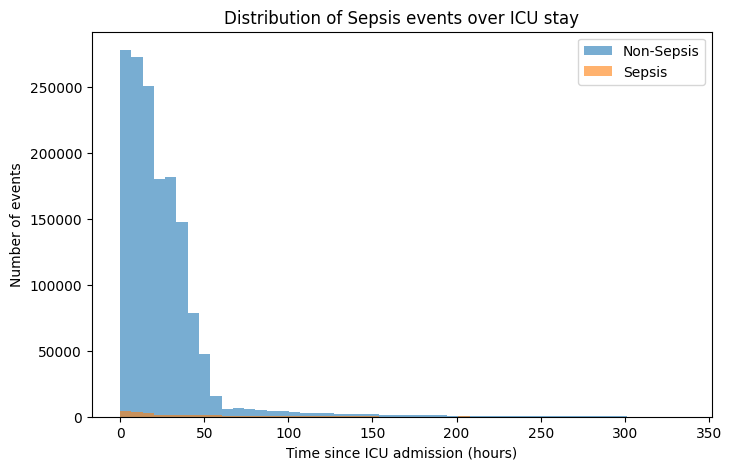

In [4]:
import matplotlib.pyplot as plt

# Sepsis vs Non-sepsis theo thời gian ICU (hour)
sepsis_hour = X.loc[X['SepsisLabel'] == 1, 'hour']
non_sepsis_hour = X.loc[X['SepsisLabel'] == 0, 'hour']

plt.figure(figsize=(8,5))
plt.hist(non_sepsis_hour, bins=50, alpha=0.6, label='Non-Sepsis')
plt.hist(sepsis_hour, bins=50, alpha=0.6, label='Sepsis')
plt.xlabel("Time since ICU admission (hours)")
plt.ylabel("Number of events")
plt.legend()
plt.title("Distribution of Sepsis events over ICU stay")
plt.show()


/tmp/ipykernel_17/2201329347.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sepsis_rate = X.groupby('hour_bin')['SepsisLabel'].mean()


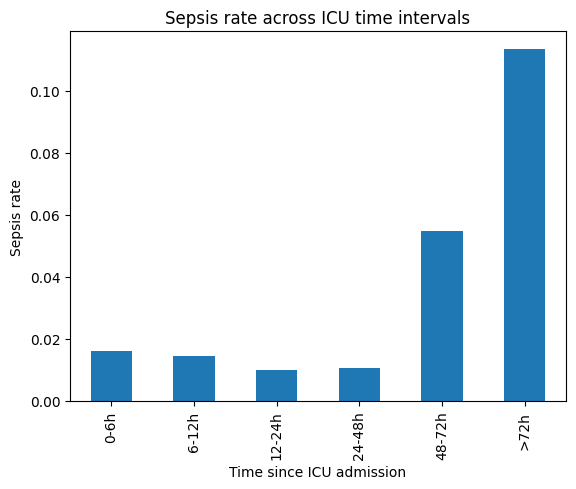

In [5]:
# Tạo bin theo giờ ICU
X['hour_bin'] = pd.cut(
    X['hour'],
    bins=[0, 6, 12, 24, 48, 72, 1000],
    labels=['0-6h', '6-12h', '12-24h', '24-48h', '48-72h', '>72h']
)

# Tính tỷ lệ Sepsis theo từng bin
sepsis_rate = X.groupby('hour_bin')['SepsisLabel'].mean()

sepsis_rate.plot(kind='bar')
plt.ylabel("Sepsis rate")
plt.xlabel("Time since ICU admission")
plt.title("Sepsis rate across ICU time intervals")
plt.show()

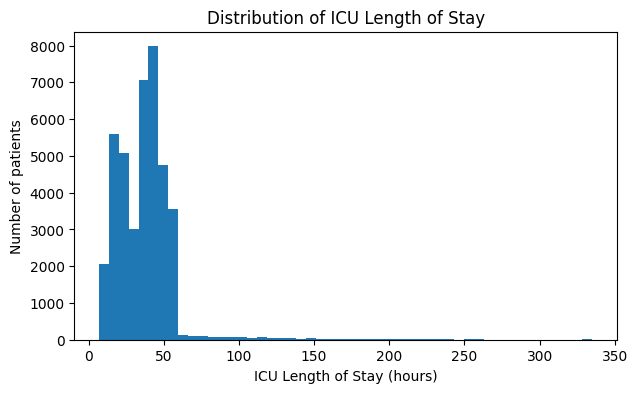

count    40336.000000
mean        37.482001
std         22.795923
min          7.000000
50%         37.000000
75%         46.000000
90%         54.000000
95%         57.000000
max        335.000000
Name: hour, dtype: float64

In [6]:
icu_los = X.groupby('id')['hour'].max()

plt.figure(figsize=(7,4))
plt.hist(icu_los, bins=50)
plt.xlabel('ICU Length of Stay (hours)')
plt.ylabel('Number of patients')
plt.title('Distribution of ICU Length of Stay')
plt.show()

icu_los.describe(percentiles=[0.5, 0.75, 0.9, 0.95])


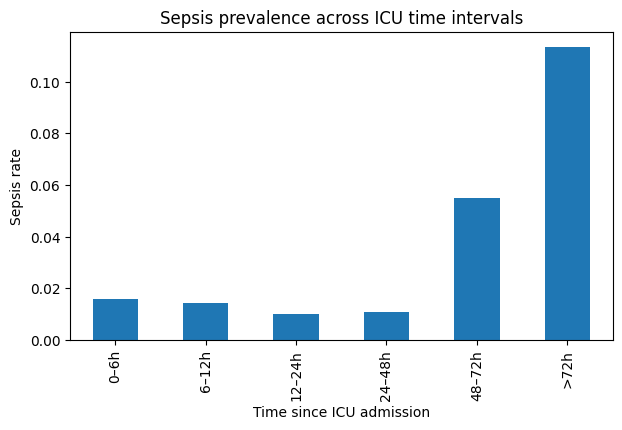

In [7]:
bins = [0, 6, 12, 24, 48, 72, X['hour'].max()]
labels = ['0–6h', '6–12h', '12–24h', '24–48h', '48–72h', '>72h']

X['hour_bin'] = pd.cut(X['hour'], bins=bins, labels=labels)

sepsis_rate = X.groupby('hour_bin', observed=False)['SepsisLabel'].mean()

plt.figure(figsize=(7,4))
sepsis_rate.plot(kind='bar')
plt.ylabel('Sepsis rate')
plt.xlabel('Time since ICU admission')
plt.title('Sepsis prevalence across ICU time intervals')
plt.show()


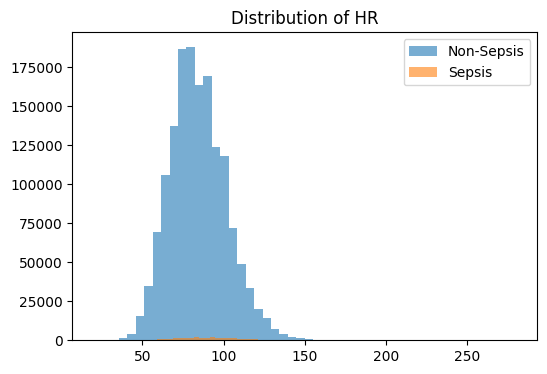

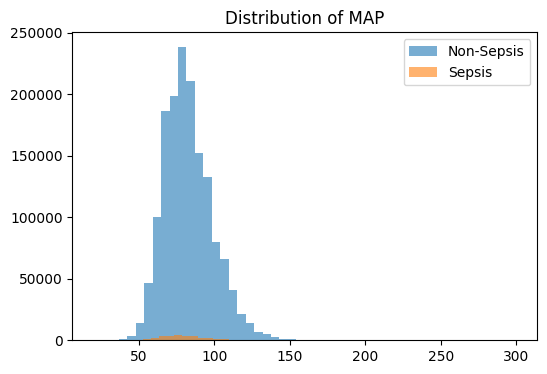

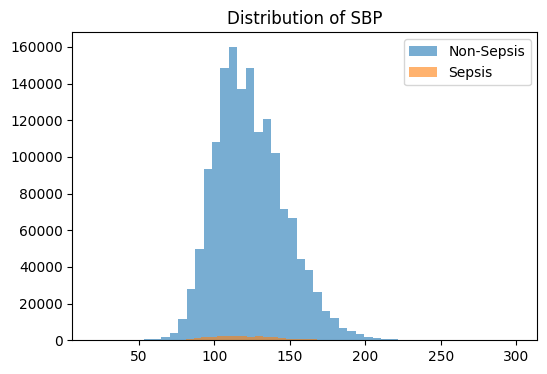

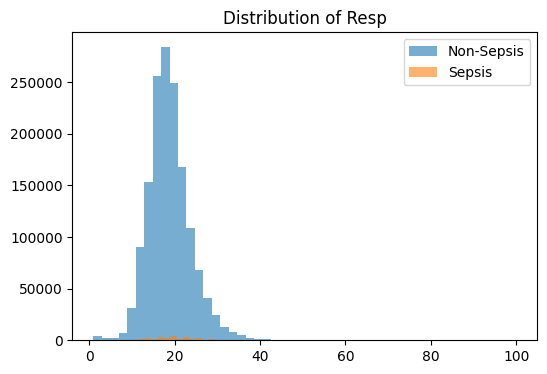

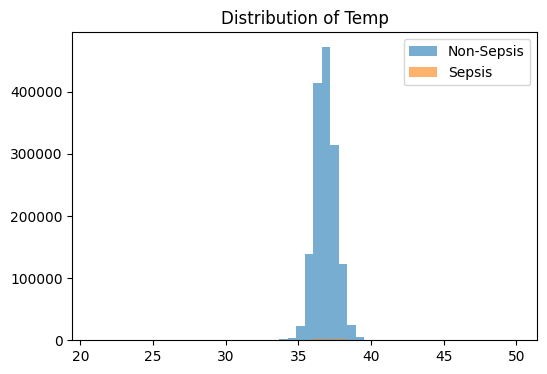

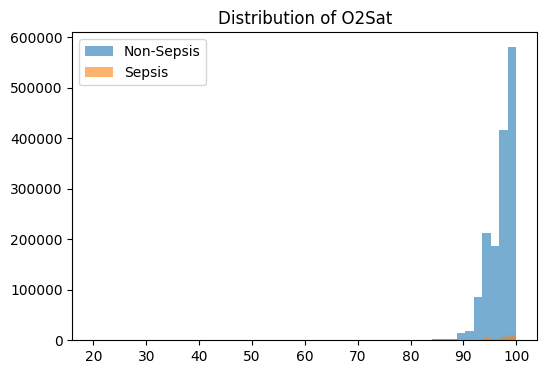

In [8]:
vitals = ['HR', 'MAP', 'SBP', 'Resp', 'Temp', 'O2Sat']

for col in vitals:
    plt.figure(figsize=(6,4))
    plt.hist(X[X['SepsisLabel']==0][col], bins=50, alpha=0.6, label='Non-Sepsis')
    plt.hist(X[X['SepsisLabel']==1][col], bins=50, alpha=0.6, label='Sepsis')
    plt.title(f'Distribution of {col}')
    plt.legend()
    plt.show()


/tmp/ipykernel_17/3237593872.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


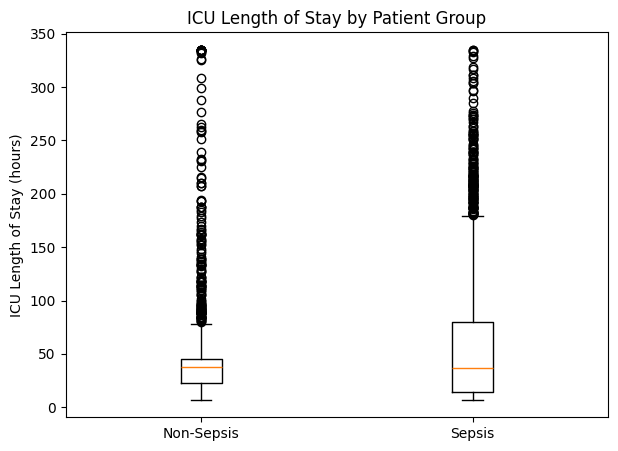

Sepsis
0    38.0
1    36.5
Name: ICU_LOS, dtype: float64

In [9]:
# ICU length of stay per patient
icu_los = X.groupby('id')['hour'].max()

# Patient-level sepsis label
patient_sepsis = X.groupby('id')['SepsisLabel'].max()

df_los = pd.DataFrame({
    'ICU_LOS': icu_los,
    'Sepsis': patient_sepsis
})

plt.figure(figsize=(7,5))
plt.boxplot(
    [df_los[df_los['Sepsis']==0]['ICU_LOS'],
     df_los[df_los['Sepsis']==1]['ICU_LOS']],
    labels=['Non-Sepsis', 'Sepsis']
)
plt.ylabel('ICU Length of Stay (hours)')
plt.title('ICU Length of Stay by Patient Group')
plt.show()

df_los.groupby('Sepsis')['ICU_LOS'].describe()
df_los.groupby('Sepsis')['ICU_LOS'].median()



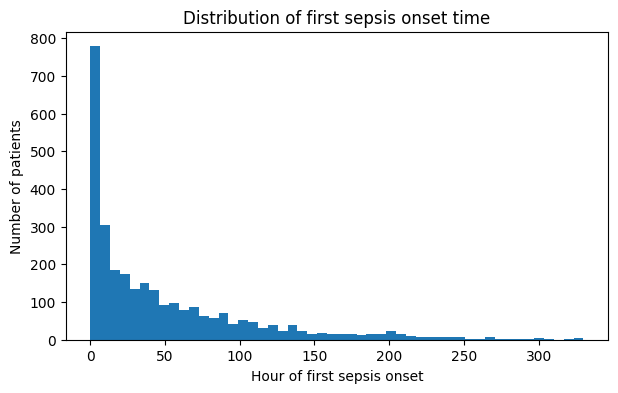

In [10]:
first_sepsis_time = (
    X[X['SepsisLabel']==1]
    .groupby('id')['hour']
    .min()
)

plt.figure(figsize=(7,4))
plt.hist(first_sepsis_time, bins=50)
plt.xlabel('Hour of first sepsis onset')
plt.ylabel('Number of patients')
plt.title('Distribution of first sepsis onset time')
plt.show()


/tmp/ipykernel_17/396563414.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


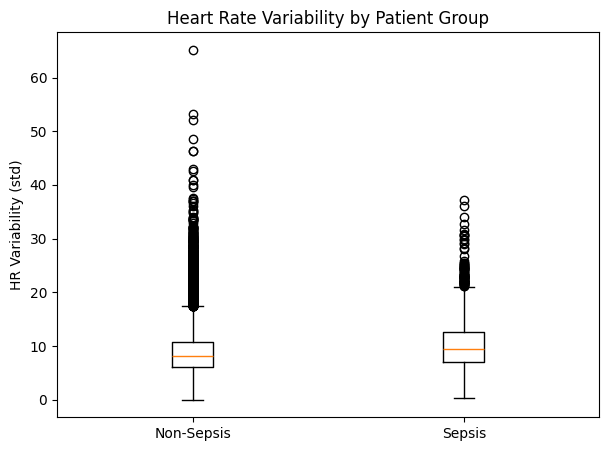

,count,mean,std,min,25%,50%,75%,max
Sepsis,,,,,,,,
0,37404.0,8.860179,4.020312,0.000000,6.190913,8.153708,10.706109,65.161338
1,2932.0,10.153011,4.625717,0.258199,6.968985,9.496878,12.628169,37.248089


In [11]:
# HR variability per patient
hr_var = X.groupby('id')['HR'].std()
patient_sepsis = X.groupby('id')['SepsisLabel'].max()

df_hrv = pd.DataFrame({
    'HR_std': hr_var,
    'Sepsis': patient_sepsis
})

plt.figure(figsize=(7,5))
plt.boxplot(
    [df_hrv[df_hrv['Sepsis']==0]['HR_std'],
     df_hrv[df_hrv['Sepsis']==1]['HR_std']],
    labels=['Non-Sepsis', 'Sepsis']
)
plt.ylabel('HR Variability (std)')
plt.title('Heart Rate Variability by Patient Group')
plt.show()

df_hrv.groupby('Sepsis')['HR_std'].describe()
